# Benchmark · Expresión facial · Bloque 3

**Responsable:** …
**Fecha:** 2026-10-07

Comparamos los tres candidatos de expresión facial:

- **HSEmotion**: modelo especializado, entrenado para emociones faciales y valence/arousal.
- **SigLIP zero-shot**: modelo general texto-imagen (familia de CLIP) al que solo le describimos las emociones con frases.
- **py-feat**: caja de herramientas de análisis facial; además de emociones da **Action Units** (FACS).

El proceso de vídeo a `face.csv` está explicado en `docs/b3_proceso_expresion_facial.ipynb`; aquí solo cambia el modelo que analiza cada recorte de cara.

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")  # Windows sin symlinks: la caché funciona igual
warnings.filterwarnings("ignore", module="feat")                # avisos informativos de py-feat al cargar

# Raíz del repo, tanto si el notebook se ejecuta desde benchmarks/ como desde la raíz
ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import cv2
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)  # oculta avisos internos de OpenCV 5
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub.utils import logging as hub_logging
from transformers.utils import logging as hf_logging
hub_logging.set_verbosity_error()  # oculta avisos de descarga de Hugging Face
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

from src.config import RAW_DIR, event_dir, load_config
from src.vision.detect import FaceDetector
from src.vision.face import analyze_video
from src.vision.models import get_face_backend
from src.vision.models.siglip import AROUSAL_PROMPTS, EMOTION_PROMPTS, TEMPLATES, VALENCE_PROMPTS
from src.vision.schema import ACTION_UNITS, EMOTIONS

cfg = load_config()
EVENT = cfg["reference_event"]
VIDEO = RAW_DIR / f"{EVENT}.mp4"
RESULTS = ROOT / "benchmarks" / "results"
MODELS = {"hsemotion": "HSEmotion", "siglip": "SigLIP", "pyfeat": "py-feat"}
COLORS = {"hsemotion": "#d35400", "siglip": "#2471a3", "pyfeat": "#1e8449"}
print(EVENT, VIDEO.exists())

2026-09-10 True


## 1. Objetivo

La etapa de expresión facial recibe el recorte de la cara de la presidenta (un fotograma por segundo) y devuelve 8 probabilidades de emoción, **valence** (agradable ↔ desagradable) y **arousal** (calmada ↔ activada) en [−1, 1] y, si el modelo los da, tres **Action Units**. Esas series son la señal visual que luego se cruza con el texto y la voz.

**Preguntas del benchmark:**
1. ¿Un modelo general texto-imagen en zero-shot (SigLIP, de la familia de CLIP vista en clase) da una señal tan útil como un modelo especializado (HSEmotion)?
2. ¿Aportan los Action Units de py-feat algo que no den las emociones, en una cara tan contenida como la de una banquera central?
3. ¿A qué coste (tiempo, memoria, dependencias)?

## 2. Candidatos

| Modelo | Qué da | Tamaño | Licencia | Local / API | Por qué se incluye |
|---|---|---|---|---|---|
| HSEmotion `enet_b0_8_va_mtl` (Savchenko, 2022) | 8 emociones + valence/arousal | ~16 MB (ONNX, EfficientNet-B0) | Apache 2.0 | Local, CPU (onnxruntime) | Especializado: entrenado en AffectNet |
| SigLIP `google/siglip-base-patch16-224` (Zhai et al., 2023) | 8 emociones + valence/arousal por zero-shot | ~800 MB (203 M parámetros) | Apache 2.0 | Local, CPU (PyTorch) | Generalista texto-imagen: clasifica sin entrenar comparando con frases |
| py-feat 2.1 (Cheong et al., 2023): ResMaskNet + AU XGBoost | 7 emociones (sin *contempt*) + 20 Action Units | ~1,3 GB de pesos (carga también modelos que no usamos) | MIT | Local, CPU (PyTorch + XGBoost) | Único con Action Units, que miden gestos concretos |

### Cómo usamos SigLIP en zero-shot

SigLIP convierte la imagen y cada frase en un vector del mismo espacio; cuanto más se parecen (similitud coseno), más «encaja» la frase con la imagen. Para cada emoción escribimos varias frases (sinónimos × plantillas) y promediamos sus vectores (*prompt ensembling*). La emoción es un softmax sobre las 8 puntuaciones. Valence y arousal no son clases, así que las sacamos enfrentando dos polos opuestos: `valence = P(agradable) − P(desagradable)`.

In [2]:
print("Plantillas:", *TEMPLATES, sep="\n  ")
print("\nEmociones:")
for e, d in EMOTION_PROMPTS.items():
    print(f"  {e:<10} {d}")
print("\nValence  +", VALENCE_PROMPTS[0], " −", VALENCE_PROMPTS[1])
print("Arousal  +", AROUSAL_PROMPTS[0], " −", AROUSAL_PROMPTS[1])
print("\nEjemplo de frase:", TEMPLATES[0].format(EMOTION_PROMPTS["anger"][0]))

Plantillas:
  a photo of {} face.
  a close-up photo of a person with {} expression.
  {} face.

Emociones:
  neutral    ['a neutral', 'an expressionless']
  happiness  ['a happy', 'a smiling']
  sadness    ['a sad', 'a sorrowful']
  surprise   ['a surprised', 'an astonished']
  fear       ['a fearful', 'a scared']
  anger      ['an angry', 'a furious']
  disgust    ['a disgusted', 'a repulsed']
  contempt   ['a contemptuous', 'a scornful']

Valence  + ['a pleasant', 'a warm and friendly']  − ['an unpleasant', 'a cold and hostile']
Arousal  + ['an excited and agitated', 'a tense and alert']  − ['a calm and relaxed', 'a sleepy and bored']

Ejemplo de frase: a photo of an angry face.


### Cómo usamos py-feat

- **Emociones:** ResMaskNet, una ResNet con máscara de atención entrenada en FER2013. Da 7 emociones: no tiene *contempt*, que queda a 0.
- **Action Units:** el sistema FACS describe la cara como movimientos de músculos concretos. py-feat localiza 68 puntos de la cara (MobileFaceNet), calcula descriptores HOG (bordes y texturas) alrededor de ellos y un clasificador XGBoost por AU da la probabilidad de que esté activa. De las 20 AU guardamos las tres del contrato:

| Columna | AU | Gesto | Lectura |
|---|---|---|---|
| `au04_brow_lowerer` | AU04 | Bajar y juntar las cejas | Ceño fruncido: preocupación, concentración |
| `au12_lip_corner_puller` | AU12 | Tirar de las comisuras hacia arriba | Sonrisa |
| `au24_lip_pressor` | AU24 | Apretar los labios | Tensión, contención |

- **No da valence ni arousal.**
- **Encuadre:** los tres modelos reciben el mismo recorte (la cara elegida por YuNet). Dentro de él, py-feat pasa su propio detector (RetinaFace) para encuadrar la cara como espera el modelo de AU: los HOG son muy sensibles al encuadre y con la caja de YuNet AU12 salía muy distinto del pipeline oficial de py-feat.

## 3. Datos de referencia

**Todavía no hay etiquetas hechas a mano**, así que este benchmark no puede decir qué modelo *acierta* más. Lo que sí mide:

- **Acuerdo entre modelos** en los ~2.400 segundos en que la presidenta está en primer plano en la rueda de referencia (10/09/2026). Los tres modelos reciben exactamente los mismos recortes: `analyze_video` es el mismo para todos y solo cambia el backend.
- **Sesgos** de cada modelo (qué emociones tiende a dar siempre).
- **Si conservan la señal útil**: la diferencia entre la declaración leída y la ronda de preguntas que se ve en el notebook del proceso.
- **Validez de los AU**: si se mueven con lo que deberían (AU12 con la alegría, por ejemplo).
- **Inspección visual** de los segundos en que más discrepan.

HSEmotion se lee del `face.csv` ya generado. SigLIP y py-feat se ejecutan sobre el vídeo completo (~8 y ~10 min en CPU) y se guardan en `benchmarks/results/`; pon `RECALCULAR = True` para repetirlo.

In [3]:
RECALCULAR = False

face = {"hsemotion": pd.read_csv(event_dir(EVENT) / "face.csv")}
for name in ["siglip", "pyfeat"]:
    path = RESULTS / f"b3_01_face_{name}_{EVENT}.csv"
    if RECALCULAR or not path.exists():
        t0 = time.perf_counter()
        analyze_video(VIDEO, get_face_backend(name)).to_csv(path, index=False)
        print(f"{MODELS[name]} sobre el vídeo completo: {time.perf_counter() - t0:.0f} s")
    face[name] = pd.read_csv(path)

# Segundos en que la presidenta está en primer plano (la identificación es la misma en todos)
for name in ["siglip", "pyfeat"]:
    assert (face["hsemotion"]["person"].fillna("") == face[name]["person"].fillna("")).all()
mask = face["hsemotion"]["person"] == "presidenta"
pres = {name: df[mask].set_index("start") for name, df in face.items()}
hse, sig, pyf = pres["hsemotion"], pres["siglip"], pres["pyfeat"]
P = [f"p_{e}" for e in EMOTIONS]
AU = list(ACTION_UNITS)
print(f"{mask.sum()} segundos de la presidenta en primer plano (de {len(face['hsemotion'])})")

2439 segundos de la presidenta en primer plano (de 3052)


## 4. Métrica

Sin etiquetas, medimos **acuerdo** y **utilidad de la señal**:

- **Correlación (Pearson y Spearman) de valence y arousal** entre HSEmotion y SigLIP (py-feat no los da), segundo a segundo y con la media móvil de 30 s que usa el resto del proyecto. Spearman no depende de la escala: si un modelo está desplazado o comprimido pero ordena igual los momentos, sigue dando correlación alta.
- **Acuerdo en la emoción principal** (top-1) por parejas y matrices de confusión.
- **Distribución media de emociones**: revela sesgos (una clase que sale siempre).
- **Diferencia declaración vs. preguntas** (d de Cohen): la señal que el notebook del proceso encontró con HSEmotion.
- **Validez convergente de los AU**: correlación de cada AU con las emociones y la valence de los otros modelos.

Cuando existan las ~100 imágenes etiquetadas a mano, se añadirá la exactitud por emoción y el CCC (*concordance correlation coefficient*) de valence/arousal, la métrica estándar en AffectNet.

## 5. Resultados

### 5.1 Valence y arousal (HSEmotion frente a SigLIP)

In [4]:
def smooth(s):
    return s.rolling(30, min_periods=10, center=True).mean()

rows = []
for dim in ["valence", "arousal"]:
    for label, f in [("por segundo", lambda s: s), ("media móvil 30 s", smooth)]:
        a, b = f(hse[dim]), f(sig[dim])
        ok = a.notna() & b.notna()
        rows.append({"dimensión": dim, "serie": label,
                     "pearson": a[ok].corr(b[ok]), "spearman": a[ok].corr(b[ok], method="spearman"),
                     "media HSEmotion": a[ok].mean(), "media SigLIP": b[ok].mean(),
                     "desv. HSEmotion": a[ok].std(), "desv. SigLIP": b[ok].std()})
corr = pd.DataFrame(rows).round(2)
corr

,dimensión,serie,pearson,spearman,media HSEmotion,media SigLIP,desv. HSEmotion,desv. SigLIP
0,valence,por segundo,0.48,0.50,-0.12,0.51,0.22,0.26
1,valence,media móvil 30 s,0.76,0.76,-0.12,0.51,0.11,0.12
2,arousal,por segundo,0.39,0.38,0.11,0.34,0.15,0.23
3,arousal,media móvil 30 s,0.34,0.38,0.11,0.34,0.06,0.08


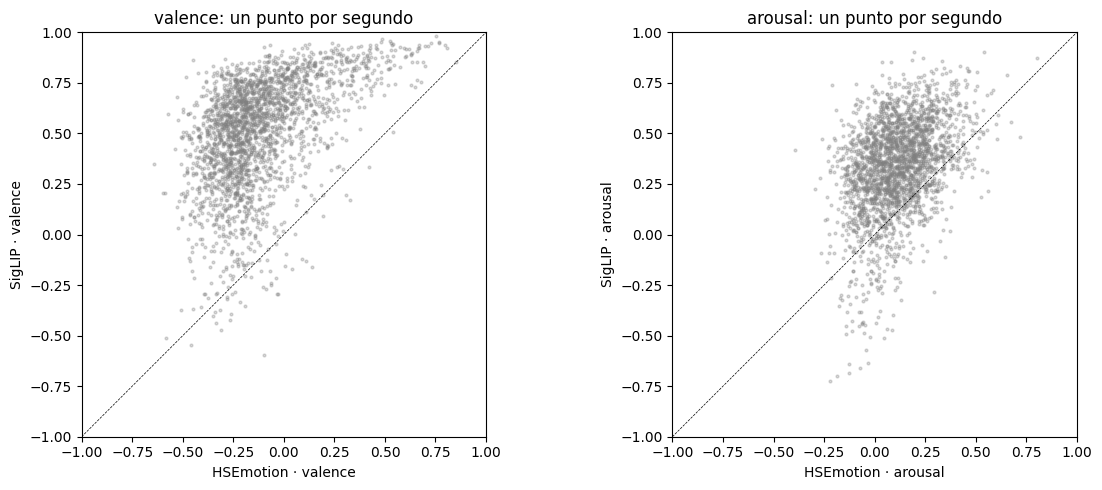

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dim in zip(axes, ["valence", "arousal"]):
    ax.scatter(hse[dim], sig[dim], s=4, alpha=0.3, color="grey")
    ax.plot([-1, 1], [-1, 1], color="black", lw=0.5, ls="--")
    ax.set(xlim=(-1, 1), ylim=(-1, 1), xlabel=f"HSEmotion · {dim}", ylabel=f"SigLIP · {dim}",
           title=f"{dim}: un punto por segundo")
    ax.set_aspect("equal")
plt.tight_layout()

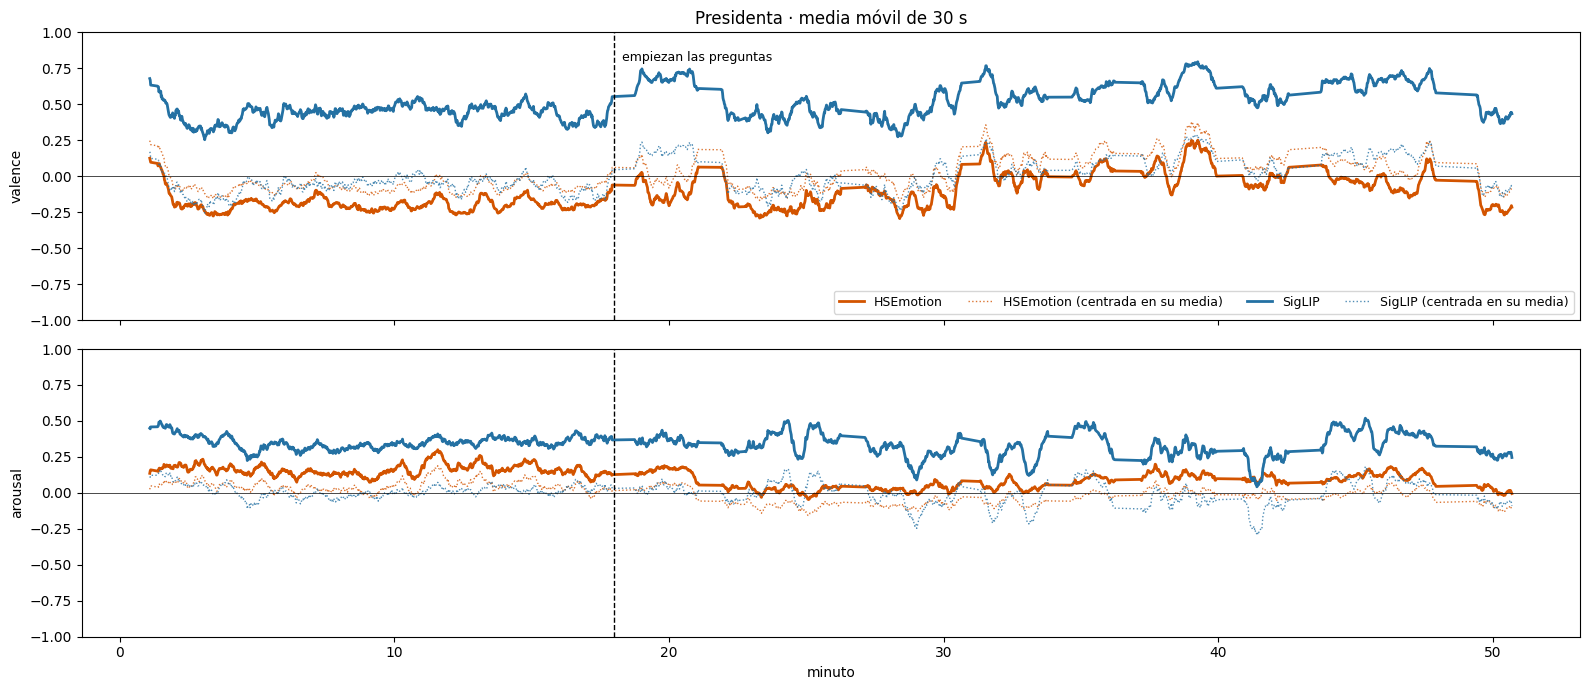

In [6]:
others = face["hsemotion"].loc[face["hsemotion"]["person"] == "otro", "start"]
first_question = others[others > 120].min()  # primer periodista tras la apertura (como en el notebook del proceso)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
for ax, dim in zip(axes, ["valence", "arousal"]):
    for name, df in [("hsemotion", hse), ("siglip", sig)]:
        s = smooth(df[dim])
        ax.plot(s.index / 60, s, color=COLORS[name], lw=2, label=MODELS[name])
        # Misma serie centrada en su propia media: compara la forma, no el nivel
        ax.plot(s.index / 60, s - s.mean(), color=COLORS[name], lw=1, ls=":", alpha=0.8,
                label=f"{MODELS[name]} (centrada en su media)")
    ax.axvline(first_question / 60, color="black", ls="--", lw=1)
    ax.axhline(0, color="black", lw=0.5)
    ax.set(ylabel=dim, ylim=(-1, 1))
axes[0].text(first_question / 60 + 0.3, 0.8, "empiezan las preguntas", fontsize=9)
axes[0].legend(loc="lower right", ncol=4, fontsize=9)
axes[0].set_title("Presidenta · media móvil de 30 s")
axes[1].set_xlabel("minuto")
plt.tight_layout()

### 5.2 Declaración frente a preguntas

¿Ven los modelos la misma diferencia entre la parte leída y la improvisada? Además de las medias, el tamaño del efecto (d de Cohen: diferencia de medias en desviaciones típicas) permite comparar señales con escalas distintas, incluidos los AU de py-feat.

In [7]:
section = np.where(hse.index < first_question, "declaración", "preguntas")

def cohen(series):
    g = series.groupby(section)
    m, s = g.mean(), g.std()
    pooled = np.sqrt((s["declaración"] ** 2 + s["preguntas"] ** 2) / 2)
    return m["declaración"], m["preguntas"], (m["preguntas"] - m["declaración"]) / pooled

signals = [("HSEmotion", "valence", hse), ("HSEmotion", "arousal", hse),
           ("SigLIP", "valence", sig), ("SigLIP", "arousal", sig)]
signals += [("py-feat", au, pyf) for au in AU]
rows = []
for name, col, df in signals:
    d_mean, q_mean, d = cohen(df[col])
    rows.append({"modelo": name, "señal": col, "declaración": d_mean, "preguntas": q_mean,
                 "diferencia": q_mean - d_mean, "d de Cohen": d})
sections = pd.DataFrame(rows).round(2)
sections

,modelo,señal,declaración,preguntas,diferencia,d de Cohen
0,HSEmotion,valence,-0.19,-0.07,0.12,0.57
1,HSEmotion,arousal,0.16,0.08,-0.08,-0.57
2,SigLIP,valence,0.44,0.56,0.12,0.48
3,SigLIP,arousal,0.35,0.33,-0.02,-0.11
4,py-feat,au04_brow_lowerer,0.20,0.27,0.07,0.41
5,py-feat,au12_lip_corner_puller,0.12,0.20,0.09,0.48
6,py-feat,au24_lip_pressor,0.45,0.46,0.00,0.03


### 5.3 Emociones

In [8]:
top = pd.DataFrame({name: df[P].idxmax(axis=1).str[2:] for name, df in pres.items()})

def chance(a, b):
    # Acuerdo esperado si cada modelo eligiera al azar con sus propias frecuencias
    fa, fb = top[a].value_counts(normalize=True), top[b].value_counts(normalize=True)
    return sum(fa.get(e, 0) * fb.get(e, 0) for e in EMOTIONS)

pairs = [("hsemotion", "siglip"), ("hsemotion", "pyfeat"), ("siglip", "pyfeat")]
agreement = pd.DataFrame([{"pareja": f"{MODELS[a]} – {MODELS[b]}",
                           "acuerdo top-1": (top[a] == top[b]).mean(), "al azar": chance(a, b)}
                          for a, b in pairs]).round(3)
print("Emoción principal más frecuente:",
      {MODELS[n]: f"{top[n].value_counts().idxmax()} ({top[n].value_counts(normalize=True).max():.0%})" for n in MODELS})
agreement

Emoción principal más frecuente: {'HSEmotion': 'surprise (28%)', 'SigLIP': 'contempt (92%)', 'py-feat': 'neutral (79%)'}


,pareja,acuerdo top-1,al azar
0,HSEmotion – SigLIP,0.048,0.035
1,HSEmotion – py-feat,0.328,0.228
2,SigLIP – py-feat,0.071,0.056


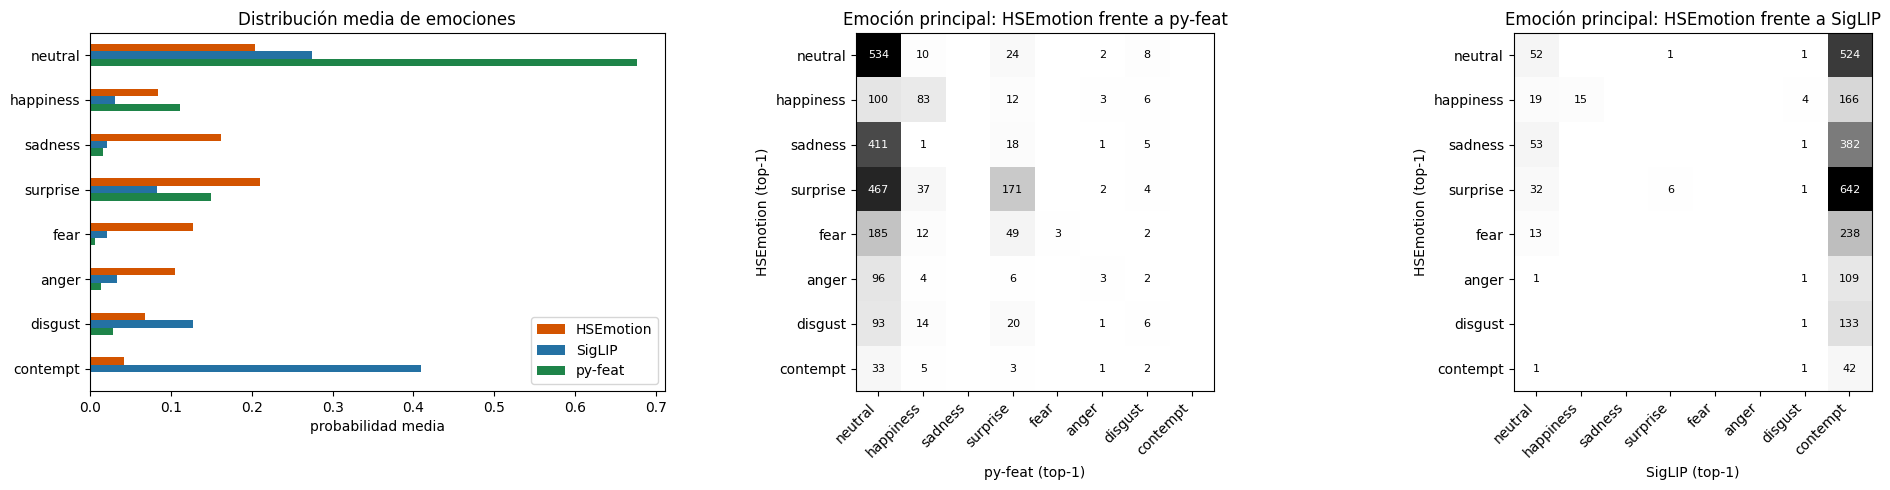

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={"width_ratios": [1, 1, 1]})
means = pd.DataFrame({MODELS[n]: df[P].mean().values for n, df in pres.items()}, index=EMOTIONS)
means.plot.barh(ax=axes[0], color=[COLORS[n] for n in MODELS])
axes[0].invert_yaxis(); axes[0].set(xlabel="probabilidad media", title="Distribución media de emociones")

for ax, (a, b) in zip(axes[1:], [("hsemotion", "pyfeat"), ("hsemotion", "siglip")]):
    cm = pd.crosstab(top[a], top[b]).reindex(index=EMOTIONS, columns=EMOTIONS, fill_value=0)
    ax.imshow(cm, cmap="Greys")
    ax.set(xticks=range(8), yticks=range(8), xlabel=f"{MODELS[b]} (top-1)", ylabel=f"{MODELS[a]} (top-1)",
           title=f"Emoción principal: {MODELS[a]} frente a {MODELS[b]}")
    ax.set_xticklabels(EMOTIONS, rotation=45, ha="right"); ax.set_yticklabels(EMOTIONS)
    for i in range(8):
        for j in range(8):
            v = cm.values[i, j]
            if v:
                ax.text(j, i, v, ha="center", va="center", fontsize=8,
                        color="white" if v > cm.values.max() / 2 else "black")
plt.tight_layout()

### 5.4 Action Units (py-feat)

Primero, cómo se reparten y cómo evolucionan a lo largo de la rueda. Después, una comprobación de **validez convergente**: si AU12 (sonrisa) mide de verdad la sonrisa, debería subir cuando HSEmotion ve alegría y valence positiva; AU04 (ceño) debería ir con valence negativa.

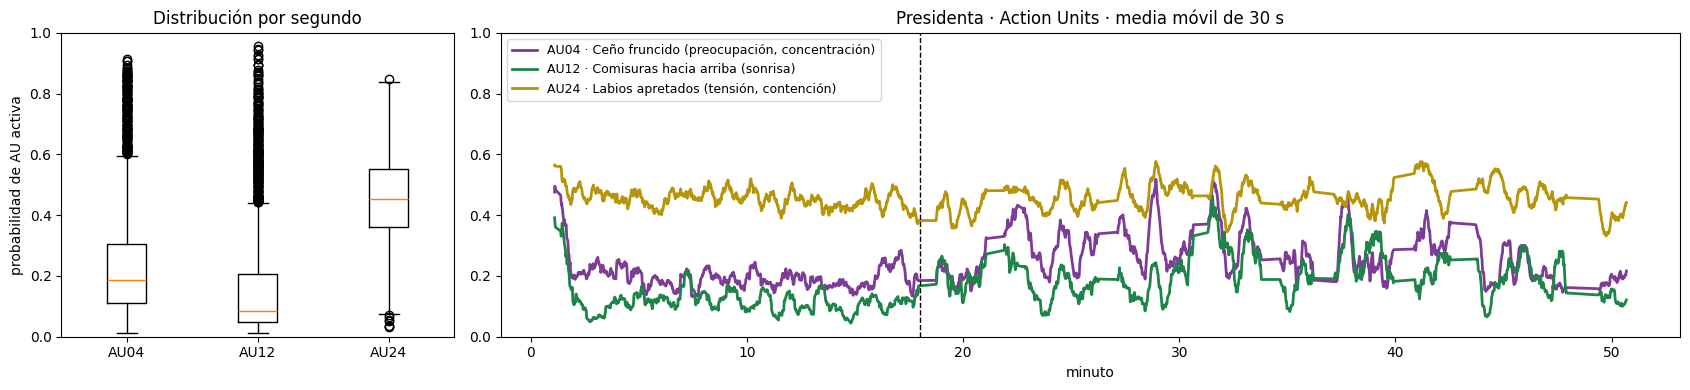

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 4), gridspec_kw={"width_ratios": [1, 3]})
axes[0].boxplot([pyf[a].dropna() for a in AU], tick_labels=[a.split("_")[0].upper() for a in AU])
axes[0].set(ylim=(0, 1), ylabel="probabilidad de AU activa", title="Distribución por segundo")
au_colors = ["#7d3c98", "#1e8449", "#b7950b"]
for a, c in zip(AU, au_colors):
    s = smooth(pyf[a])
    axes[1].plot(s.index / 60, s, color=c, lw=2, label=f"{a.split('_')[0].upper()} · {ACTION_UNITS[a]}")
axes[1].axvline(first_question / 60, color="black", ls="--", lw=1)
axes[1].set(ylim=(0, 1), xlabel="minuto", title="Presidenta · Action Units · media móvil de 30 s")
axes[1].legend(loc="upper left", fontsize=9)
plt.tight_layout()

In [11]:
ref = {"HSE valence": hse["valence"], "HSE alegría": hse["p_happiness"],
       "HSE enfado": hse["p_anger"], "HSE tristeza": hse["p_sadness"],
       "SigLIP valence": sig["valence"],
       "py-feat alegría": pyf["p_happiness"], "py-feat neutral": pyf["p_neutral"]}
validity = pd.DataFrame({a.split("_")[0].upper(): {k: pyf[a].corr(v, method="spearman") for k, v in ref.items()}
                         for a in AU}).T.round(2)
print("Spearman por segundo entre cada AU y otras señales")
validity

Spearman por segundo entre cada AU y otras señales


,HSE valence,HSE alegría,HSE enfado,HSE tristeza,SigLIP valence,py-feat alegría,py-feat neutral
AU04,0.05,0.22,0.19,0.12,-0.05,-0.04,0.17
AU12,0.41,0.52,-0.12,-0.12,0.35,0.41,-0.14
AU24,0.03,0.13,0.13,0.14,0.08,-0.05,0.24


### 5.5 Dónde discrepan más

Los 6 segundos con mayor diferencia de valence entre HSEmotion y SigLIP, con lo que dice cada modelo, para ver con los ojos quién tiene más sentido.

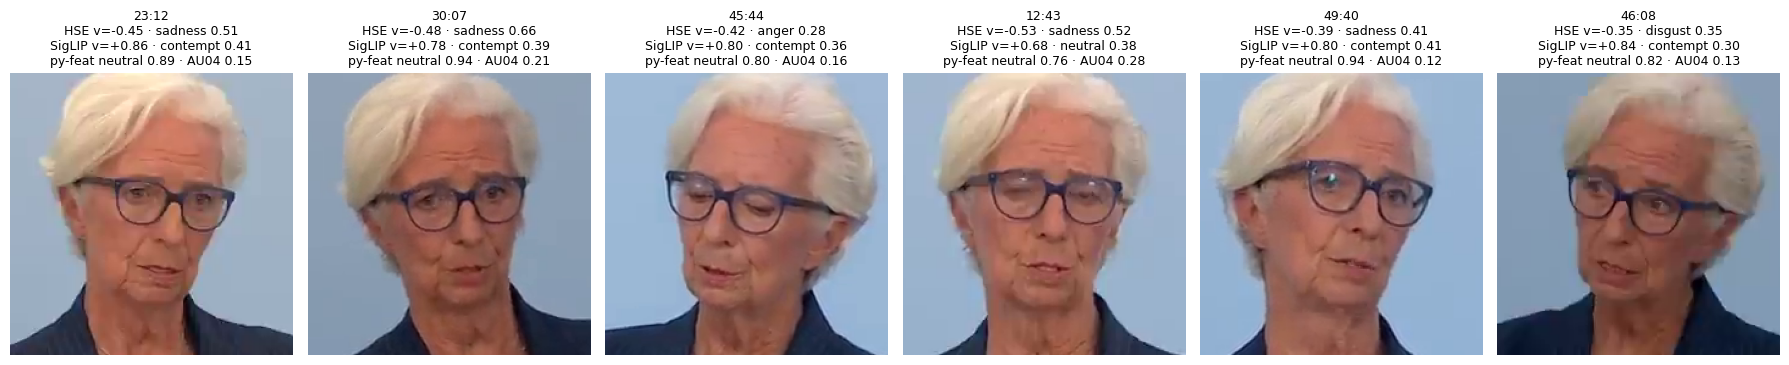

In [12]:
detector = FaceDetector()

def crop_at(second: float) -> np.ndarray:
    cap = cv2.VideoCapture(str(VIDEO))
    cap.set(cv2.CAP_PROP_POS_MSEC, second * 1000)
    _, frame = cap.read()
    cap.release()
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return detector.crop(frame, detector.detect(frame)[0])

def top_emotion(df, t):
    p = df.loc[t, P].astype(float)
    return f"{p.idxmax()[2:]} {p.max():.2f}"

gap = (hse["valence"] - sig["valence"]).abs().sort_values(ascending=False)
picked = []
for t in gap.index:  # evita segundos casi consecutivos (serían la misma imagen)
    if all(abs(t - u) > 20 for u in picked):
        picked.append(t)
    if len(picked) == 6:
        break

fig, axes = plt.subplots(1, 6, figsize=(18, 4.4))
for ax, t in zip(axes, picked):
    ax.imshow(crop_at(t)); ax.axis("off")
    ax.set_title(f"{int(t) // 60:02d}:{int(t) % 60:02d}\n"
                 f"HSE v={hse.loc[t, 'valence']:+.2f} · {top_emotion(hse, t)}\n"
                 f"SigLIP v={sig.loc[t, 'valence']:+.2f} · {top_emotion(sig, t)}\n"
                 f"py-feat {top_emotion(pyf, t)} · AU04 {pyf.loc[t, AU[0]]:.2f}", fontsize=9)
plt.tight_layout()

In [13]:
# Tabla de resultados para benchmarks/results/
def d_of(name, col):
    q = sections[(sections["modelo"] == name) & (sections["señal"] == col)]["d de Cohen"]
    return q.item() if len(q) else np.nan

summary = pd.DataFrame([
    {"modelo": MODELS[n],
     "valence_media": pres[n]["valence"].mean(), "arousal_media": pres[n]["arousal"].mean(),
     "emocion_mas_frecuente": top[n].value_counts().idxmax(),
     "pct_emocion_mas_frecuente": top[n].value_counts(normalize=True).max(),
     "d_cohen_valence_decl_vs_preg": d_of(MODELS[n], "valence"),
     "da_action_units": n == "pyfeat"}
    for n in MODELS
])
summary["corr_valence_30s_spearman_hse_siglip"] = corr.query("dimensión == 'valence' and serie == 'media móvil 30 s'")["spearman"].item()
for a, b in pairs:
    summary[f"acuerdo_top1_{a}_{b}"] = (top[a] == top[b]).mean()
summary.round(3).to_csv(RESULTS / "b3_01_resultados.csv", index=False)
summary.round(2).T

,0,1,2
modelo,HSEmotion,SigLIP,py-feat
valence_media,-0.12,0.51,NaN
arousal_media,0.11,0.34,NaN
emocion_mas_frecuente,surprise,contempt,neutral
pct_emocion_mas_frecuente,0.28,0.92,0.79
d_cohen_valence_decl_vs_preg,0.57,0.48,NaN
da_action_units,False,False,True
corr_valence_30s_spearman_hse_siglip,0.76,0.76,0.76
acuerdo_top1_hsemotion_siglip,0.05,0.05,0.05
acuerdo_top1_hsemotion_pyfeat,0.33,0.33,0.33


## 6. Latencia y memoria

Tiempo por recorte de cara (solo el modelo de expresión; la detección e identificación son comunes) medido en 30 recortes reales, y memoria que ocupa cada modelo cargado.

In [14]:
import platform

import psutil

proc = psutil.Process(os.getpid())
crops = [crop_at(t) for t in hse.index[::80][:30]]

rows = []
for name in MODELS:
    rss0 = proc.memory_info().rss
    t0 = time.perf_counter()
    backend = get_face_backend(name)
    load_s = time.perf_counter() - t0
    rss = (proc.memory_info().rss - rss0) / 2**20
    backend.analyze(crops[0])  # calentamiento
    t0 = time.perf_counter()
    for c in crops:
        backend.analyze(c)
    ms = (time.perf_counter() - t0) / len(crops) * 1000
    rows.append({"modelo": MODELS[name], "carga (s)": load_s, "RAM al cargar (MB)": rss, "ms por cara": ms,
                 "min por rueda (2.400 caras)": ms * 2400 / 1000 / 60})
    del backend

latency = pd.DataFrame(rows).round(1)
print(f"CPU: {platform.processor()} · {psutil.cpu_count(logical=False)} núcleos · sin GPU")
print("(La carga de un modelo ya usado en esta sesión es más rápida y su RAM puede salir subestimada)")
latency

CPU: AMD64 Family 26 Model 36 Stepping 0, AuthenticAMD · 12 núcleos · sin GPU
(La carga de un modelo ya usado en esta sesión es más rápida y su RAM puede salir subestimada)


,modelo,carga (s),RAM al cargar (MB),ms por cara,min por rueda (2.400 caras)
0,HSEmotion,0.2,47.0,8.9,0.4
1,SigLIP,7.7,1054.3,86.3,3.5
2,py-feat,4.3,1393.5,220.3,8.8


## 7. Decisión

**Provisional: HSEmotion sigue como modelo principal de expresión facial; py-feat queda como complemento opcional para los Action Units; SigLIP zero-shot se descarta.** Es provisional porque falta medir contra etiquetas hechas a mano.

| | HSEmotion | SigLIP zero-shot | py-feat |
|---|---|---|---|
| Valence / arousal | **Sí** | Sí, pero desplazada (+0,51 de media) | No |
| Valence: misma dinámica que HSEmotion (30 s) | — | Spearman 0,76 | — |
| Declaración → preguntas (d de Cohen) | valence 0,57 | valence 0,48 | AU12 0,48 · AU04 0,41 · AU24 0,03 |
| Emoción principal más frecuente | surprise (28 %) | **contempt (92 %)** | neutral (79 %) |
| Acuerdo top-1 con HSEmotion (azar) | — | 5 % (4 %) | 33 % (23 %) |
| Action Units | No | No | **Sí** (AU12 válida; AU04 dudosa; AU24 plana) |
| Tiempo por cara (CPU) | **~10 ms** | ~90-120 ms | ~220 ms |
| RAM | **~50 MB** | ~1 GB | ~1,4 GB |
| Minutos por rueda | **< 1** | ~4 | ~9 |

**HSEmotion, modelo principal.** Es el único que da valence y arousal propios, es el más rápido con diferencia y su señal de valence la confirman los otros dos por caminos independientes: SigLIP sigue la misma dinámica y el AU12 de py-feat se mueve con ella. Su punto débil son las emociones discretas: en una cara contenida y hablando reparte la probabilidad entre sorpresa, tristeza y miedo. En los segundos de mayor discrepancia (5.5) la presidenta aparece seria y hablando; py-feat la ve «neutral», que es lo que se ve a simple vista, mientras HSEmotion exagera la tristeza. Por eso el proyecto usa las series suavizadas y no la emoción ganadora de cada segundo.

**py-feat, complemento para los Action Units.** Sus emociones son más conservadoras (casi todo «neutral»), lo que probablemente es más fiel para esta cara, pero también da poca señal. Lo valioso son los AU:
- **AU12 (sonrisa) es válida:** se mueve con la alegría de HSEmotion (Spearman 0,52) y con la valence de HSEmotion y SigLIP (0,41 y 0,35), y sube en la ronda de preguntas.
- **AU04 (ceño) sube también en las preguntas** (d = 0,41) aunque la valence sube: la presidenta es más expresiva en general cuando improvisa (más sonrisa y más ceño), algo que la valence sola no cuenta. Pero apenas correlaciona con la valence ni con el enfado, y las gafas pueden afectarla: hay que validarla con etiquetas.
- **AU24 (labios apretados) no aporta:** está casi constante en ~0,45 y no distingue nada.

Su coste (~9 min por rueda) es asumible en el procesado por lotes de las 6-10 ruedas de la demo (~1-1,5 h en total), no en tiempo real. Si se incorpora, lo natural es que HSEmotion rellene emociones y valence/arousal y py-feat solo las columnas de AU de `face.csv`.

**SigLIP zero-shot, descartado** en esta configuración: sus emociones están dominadas por *contempt*, su valence está desplazada y su arousal apenas distingue declaración y preguntas (d = −0,11), con un coste ~10 veces mayor que HSEmotion. Su valor ha sido de validación: un modelo entrenado de forma totalmente distinta ve la misma dinámica de valence.

**Siguientes pasos:**
1. Etiquetar a mano ~100 fotogramas (emoción, y si es posible AU04/AU12) y medir exactitud y CCC; solo entonces se puede decir quién acierta.
2. Decidir en el equipo si `face.csv` incluye los AU de py-feat (backend combinado HSEmotion + py-feat) o se queda solo con HSEmotion.
3. Anotar el ganador en `config.yaml` (`face: hsemotion`) cuando se confirme.
